<a href="https://colab.research.google.com/github/bw123111/csci547_ML/blob/main/assignments/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 - Unsupervised Learning

## *Bella Wengappuly*
Netid: bw165311

Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus for additional information.

Instructions for all assignments can be found [here](https://github.com/kylebradbury/ids705/blob/master/assignments/_Assignment%20Instructions.ipynb), and is also linked to from the [course syllabus](https://kylebradbury.github.io/ids705/index.html).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

# Learning objectives
Through completing this assignment you will be able to...
1. Apply clustering techniques to a variety of datasets with diverse distributional properties, gaining an understanding of their strengths and weaknesses and how to tune model parameters
2. Apply PCA and t-SNE for performing dimensionality reduction and data visualization

# 1

## [50 points] Clustering

Clustering can be used to reveal structure between samples of data and assign group membership to similar groups of samples. This exercise will provide you with experience applying clustering algorithms and comparing these techniques on various datasets to experience the pros and cons of these approaches when the structure of the data being clustered varies. For this exercise, we'll explore clustering in two dimensions to make the results more tangible, but in practice these approaches can be applied to any number of dimensions.

**(a) Run K-means and choose the number of clusters**. Five datasets are provided for you below and the code to load them below.
- Scatterplot each dataset
- For each dataset run the k-means algorithm for values of $k$ ranging from 1 to 10 and for each plot the "elbow curve" where you plot dissimilarity in each case. Here, you can measure dissimilarity using the within-cluster sum-of-squares, which in sklean is know as "inertia" and can be accessed through the `inertia_` attribute of a fit KMeans class instance.
- For each datasets, where is the elbow in the curve of within-cluster sum-of-squares and why? Is the elbow always clearly visible? When its not clear, you will have to use your judgement in terms of selecting a reasonable number of clusters for the data. *There are also other metrics you can use to explore to measure the quality of cluster fit (but do not have to for this assignment) including the silhouette score, the Calinski-Harabasz index, and the Davies-Bouldin, to name a few within sklearn alone. However, assessing quality of fit without "preferred" cluster assignments to compare against (that is, in a truly unsupervised manner) is challenging because measuring cluster fit quality is typically poorly-defined and doesn't generalize across all types of inter- and intra-cluster variation.*
- Plot your clustered data (different color for each cluster assignment) for your best $k$-means fit determined from both the elbow curve and your judgement for each dataset and your inspection of the dataset.

**(b) Apply DBSCAN**. Vary the `eps` and `min_samples` parameters to get as close as you can to having the same number of clusters as your choices with K-means. In this case, the black points are points that were not assigned to clusters.

**(c) Apply agglomerative hierarchical clustering (AHC) Clustering**. Select the same number of clusters as selected by k-means. Plot the dendrogram with the threshold set to k.

**(d) Comment on the strengths and weaknesses of each approach**. In particular, mention:
- Which technique worked "best" and "worst" (as defined by matching how human intuition would cluster the data) on each dataset?
- How much effort was required to get good clustering for each method (how much parameter tuning needed to be done)?

*Note: for these clustering plots in this question, do NOT include legends indicating cluster assignment; instead just make sure the cluster assignments are clear from the plot (e.g. different colors for each cluster)*

Code is provided below for loading the datasets and for making plots with the clusters as distinct colors

### Import Libraries and define functions

In [1]:
# Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

In [2]:
################################
# Load the data
################################
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

# Create / load the datasets:
n_samples = 1500
X0, _ = make_blobs(n_samples=n_samples, centers=2, n_features=2, random_state=0)
X1, _ = make_blobs(n_samples=n_samples, centers=5, n_features=2, random_state=0)

random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state, cluster_std=1.3)
transformation = [[0.6, -0.6], [-0.2, 0.8]]
X2 = np.dot(X, transformation)
X3, _ = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)
X4, _ = make_moons(n_samples=n_samples, noise=.12)

X = [X0, X1, X2, X3, X4]
# The datasets are X[i], where i ranges from 0 to 4

In [3]:
################################
# Code to plot clusters
################################
def plot_cluster(ax, data, cluster_assignments):
    '''Plot two-dimensional data clusters

    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot on
    data : list or numpy array of size [N x 2]
        Clustered data
    cluster_assignments : list or numpy array [N]
        Cluster assignments for each point in data

    '''
    clusters = np.unique(cluster_assignments)
    n_clusters = len(clusters)
    for ca in clusters:
        kwargs = {}
        if ca == -1:
            # if samples are not assigned to a cluster (have a cluster assignment of -1, color them gray)
            kwargs = {'color':'gray'}
            n_clusters = n_clusters - 1
        ax.scatter(data[cluster_assignments==ca, 0], data[cluster_assignments==ca, 1],s=5,alpha=0.5, **kwargs)
        ax.set_xlabel('feature 1')
        ax.set_ylabel('feature 2')
        ax.set_title(f'No. Clusters = {n_clusters}')
        ax.axis('equal')

**ANSWER**

### Data Visualization
There are 5 datasets within array X, X0 through X4.

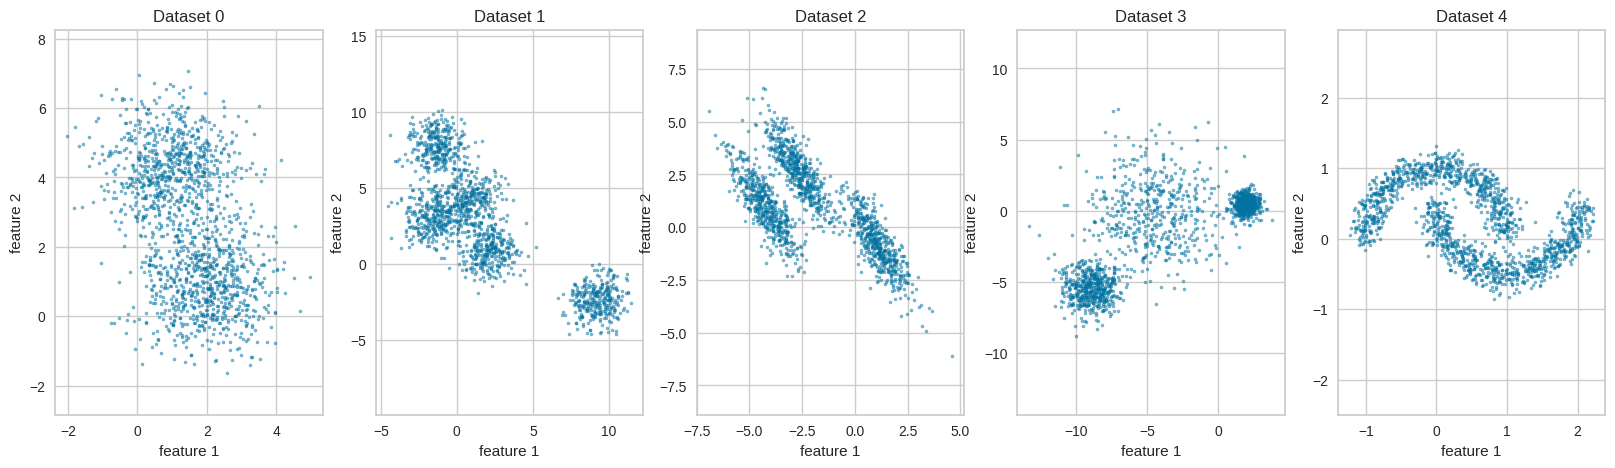

In [4]:
# plot each of 5 datasets in array X in a multipart figure on equal axes
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, dataset in enumerate(X):
    ax[i].scatter(dataset[:, 0], dataset[:, 1], s=5, alpha=0.5)
    ax[i].set_title(f'Dataset {i}')
    ax[i].set_xlabel('feature 1')
    ax[i].set_ylabel('feature 2')
    ax[i].axis('equal')
    # ax[i].label_outer()
plt.show()


In [5]:
X[i]

array([[ 0.31065607,  0.98969481],
       [ 0.91022638,  0.51527063],
       [ 1.40316106, -0.53233732],
       ...,
       [ 0.04391424,  0.31558958],
       [ 0.13478729,  0.50246374],
       [ 2.01605282,  0.35607651]])

### K Means

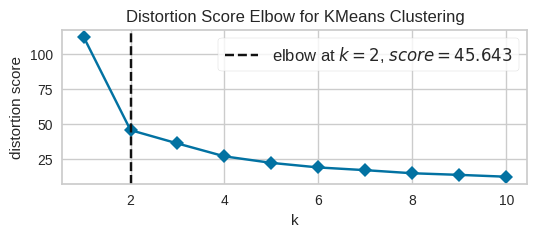

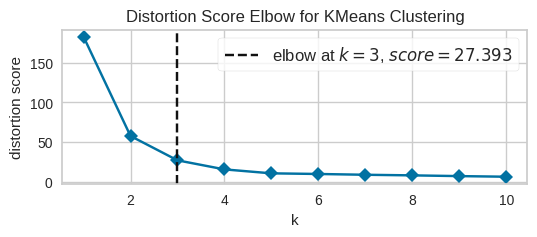

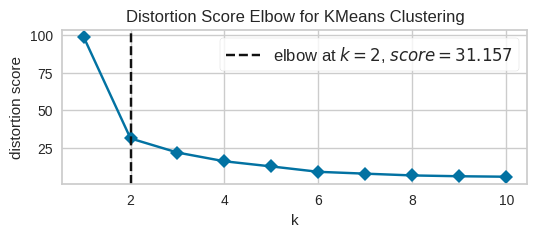

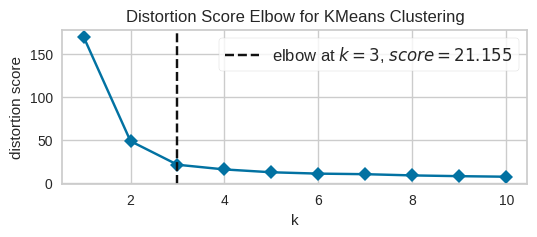

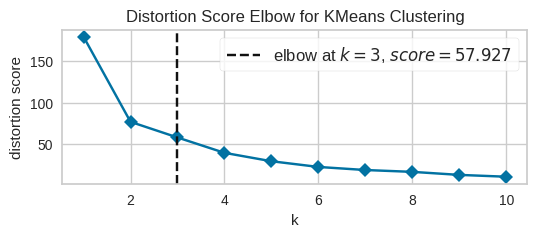

In [6]:
scaler = MinMaxScaler()
x_scaled_datasets = []

# Scale all datasets first
for dataset in X:
    x_scaled_datasets.append(scaler.fit_transform(dataset))

# Iterate through scaled datasets and plot elbow curves using KElbowVisualizer
for i, scaled_dataset in enumerate(x_scaled_datasets):
    # Instantiate the K-Means model
    model = KMeans(random_state=42, n_init='auto')

    # Instantiate the KElbowVisualizer
    # k=(1,11) for clusters from 1 to 10 (as KElbowVisualizer k is exclusive for the upper bound)
    visualizer = KElbowVisualizer(model, k=(1, 11), metric='distortion', timings=False)

    # Fit the visualizer to the data
    visualizer.fit(scaled_dataset)

    # Set the title and display the plot
    visualizer.ax.figure.set_size_inches(6, 2)
    visualizer.show(title=f'Elbow Method For Optimal k - Dataset {i}')

The elbow of the curve is present where the inertia changes sharply. This point is considered the optimal k as further increasing k no longer improves model performance significantly. This elbow is not always clearly visible, as with datasets 0, 2, 4. Some personal judgement based on the data and elbow plots is required to choose a good k. I used a function from Sklearn to identify the optimal k based on the distortion metric. However, even this doesn't show the optimal number of clusters as a human would choose K. I changed the k for datasets 1, 2, 4 according to my judgement.

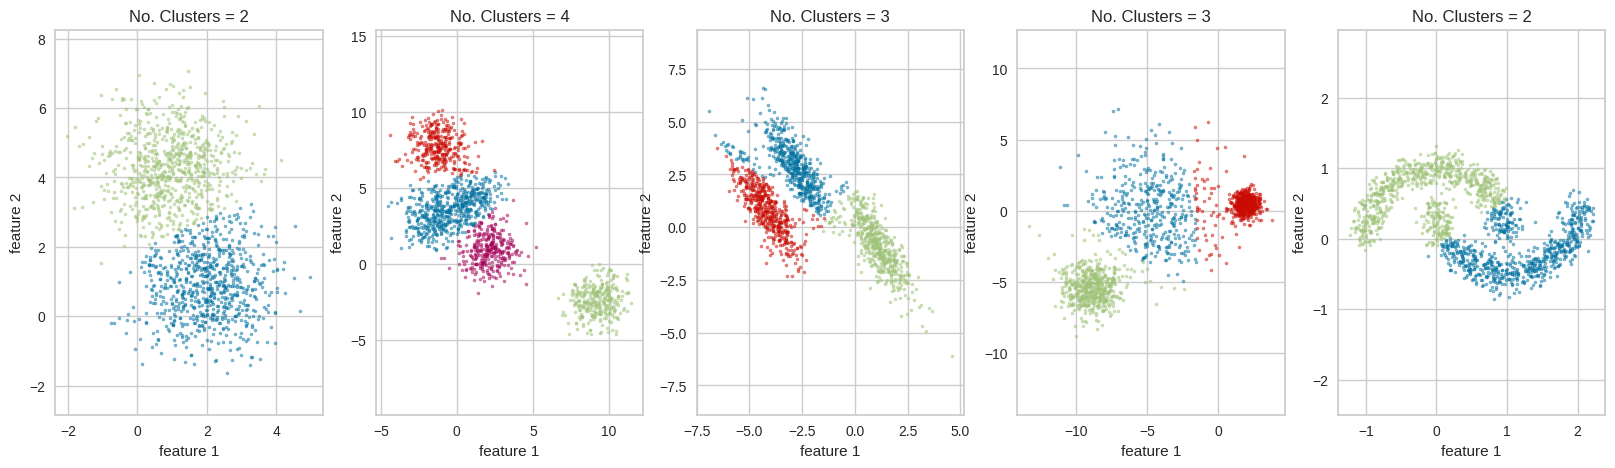

In [7]:
km_models = []
optimal_ks = [2,4,3,3,2]

# fit kmeans models for optimal k for each dataset
for i, dataset in enumerate(x_scaled_datasets):
    model = KMeans(n_clusters=optimal_ks[i], random_state=42)
    model.fit(dataset)
    km_models.append(model)

# plot clusters from each kmeans model
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, model in enumerate(km_models):
    plot_cluster(ax[i], X[i], model.labels_)


### DBSCAN
eps: specifies how close points should be to each other to be considered a part of a cluster. It means that if the distance between two points is lower or equal to this value (eps), these points are considered to be neighbors.  
minPoints: the minimum number of data points to form a dense region/ cluster. For example, if we set the minPoints parameter as 5, then we need at least 5 points to form a dense region.

Dataset 0: Target clusters = 2, Found clusters = 1, Noise points = 33
  Parameters: eps=0.4, min_samples=5
Dataset 1: Target clusters = 4, Found clusters = 14, Noise points = 306
  Parameters: eps=0.3, min_samples=7
Dataset 2: Target clusters = 3, Found clusters = 5, Noise points = 84
  Parameters: eps=0.3, min_samples=5
Dataset 3: Target clusters = 3, Found clusters = 5, Noise points = 58
  Parameters: eps=0.65, min_samples=5
Dataset 4: Target clusters = 2, Found clusters = 2, Noise points = 32
  Parameters: eps=0.1, min_samples=6


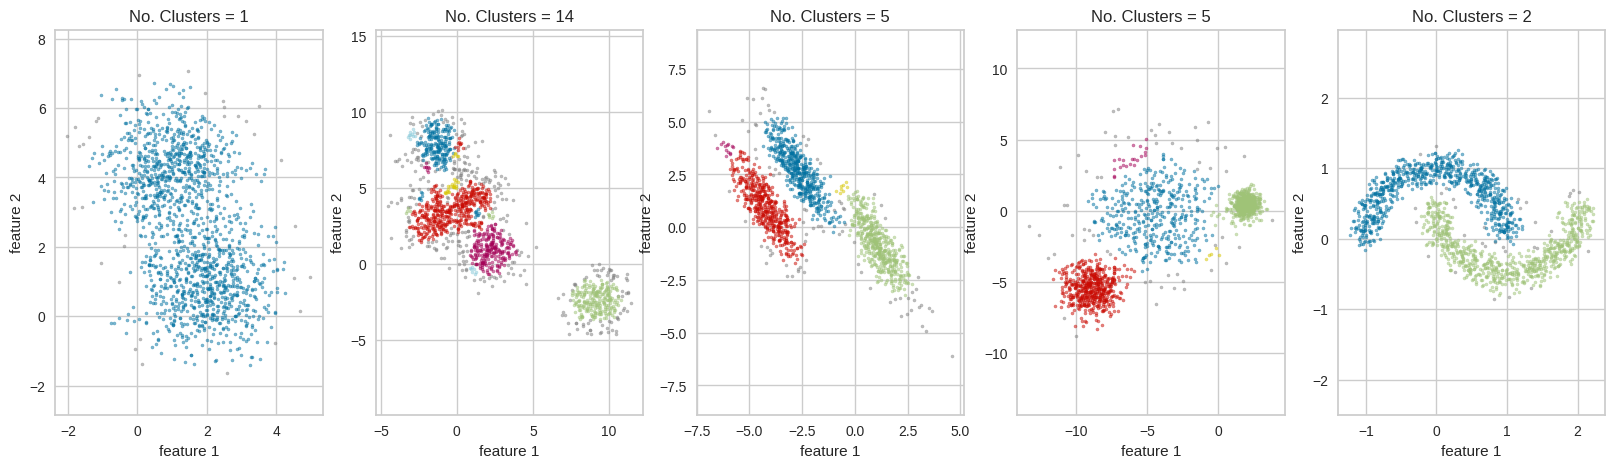

In [32]:
# Apply DBSCAN to each dataset
dbscan_models = []
labels_list = []

# Tuned parameters for each dataset to achieve target number of clusters
dbscan_params = [
    {'eps': 0.4, 'min_samples': 5},   # X0: target 2 clusters
    {'eps': 0.3, 'min_samples': 7},   # X1: target 4 clusters
    {'eps': 0.3, 'min_samples': 5},   # X2: target 3 clusters
    {'eps': 0.65, 'min_samples': 5},   # X3: target 3 clusters
    {'eps': 0.1, 'min_samples': 6},   # X4: target 2 clusters
]

for i, (data, params) in enumerate(zip(X, dbscan_params)):
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = dbscan.fit_predict(data)

    dbscan_models.append(dbscan)
    labels_list.append(labels)

    # Count clusters (excluding noise points labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"Dataset {i}: Target clusters = {optimal_ks[i]}, "
          f"Found clusters = {n_clusters}, Noise points = {n_noise}")
    print(f"  Parameters: eps={params['eps']}, min_samples={params['min_samples']}")

# plot clusters from DBSCAN models
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, dbscan in enumerate(dbscan_models):
    plot_cluster(ax[i], X[i], dbscan.labels_)

### AHC

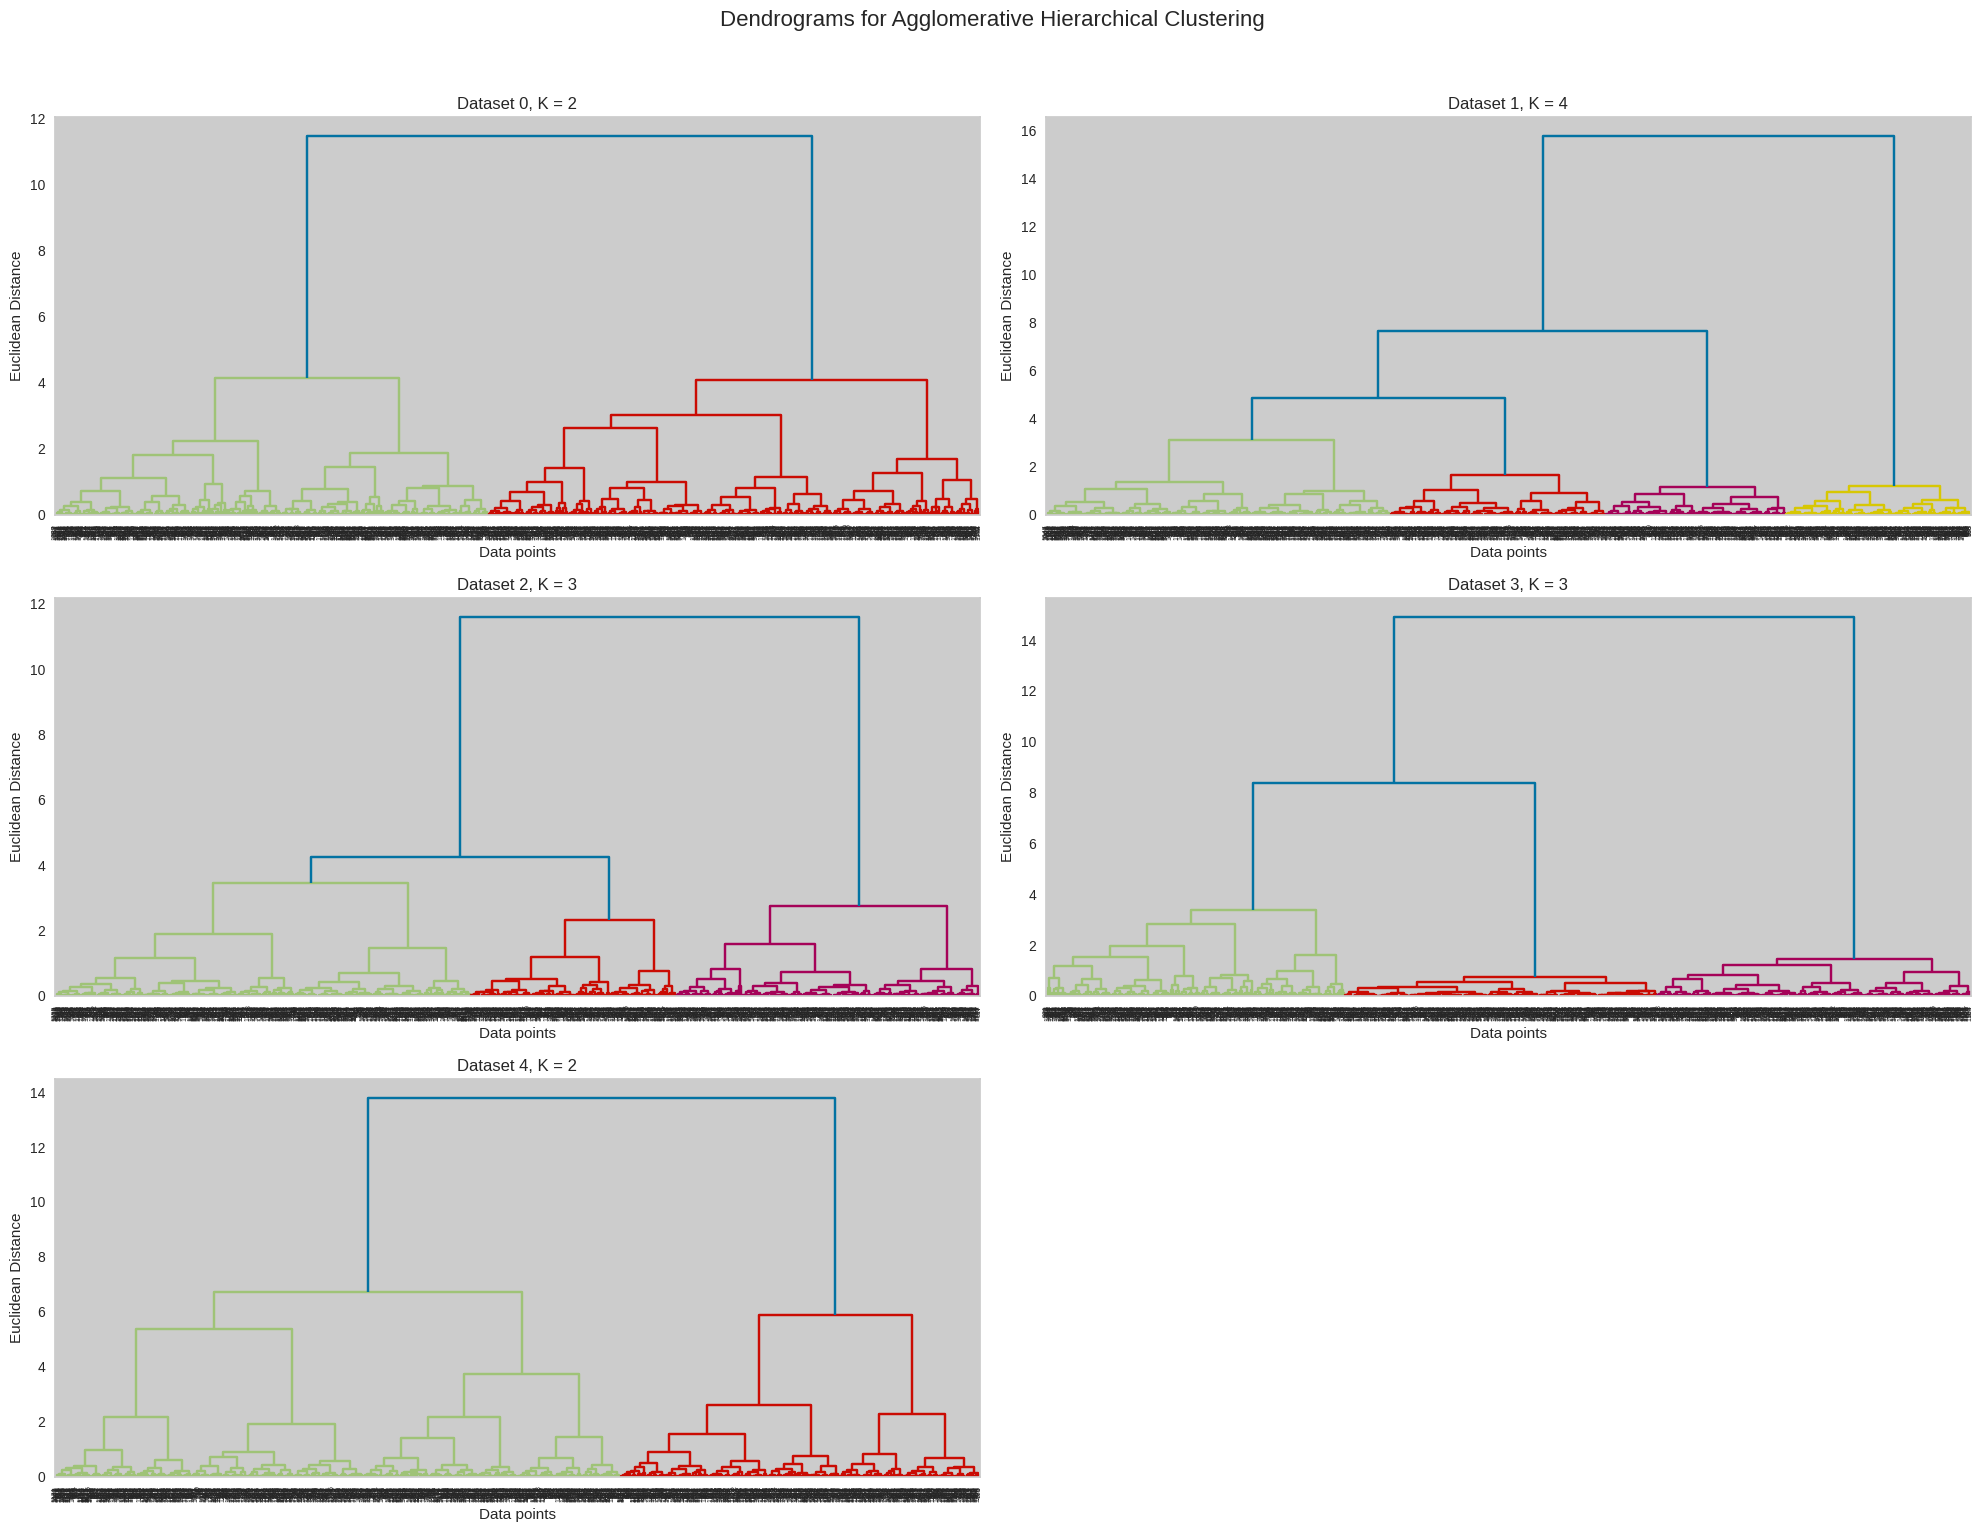

In [10]:
# Plot dendrograms for each dataset
plt.figure(figsize=(20, 15))
plt.suptitle('Dendrograms for Agglomerative Hierarchical Clustering', y=1.02, fontsize=16)

for i, dataset in enumerate(x_scaled_datasets):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    # Generate the linkage matrix
    linked = hierarchy.linkage(dataset, method='ward')

    # Plot the dendrogram with a threshold for the chosen number of clusters
    # The threshold is set to mark the optimal_ks[i] clusters.
    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
              #  show_leaf_counts=True,
               color_threshold=linked[-(optimal_ks[i]-1), 2] # Set threshold to cut at optimal_ks[i] clusters
              )
    plt.title(f'Dataset {i}, K = {optimal_ks[i]}')
    plt.xlabel(f'Data points')
    plt.ylabel('Euclidean Distance')

plt.tight_layout()
plt.show()

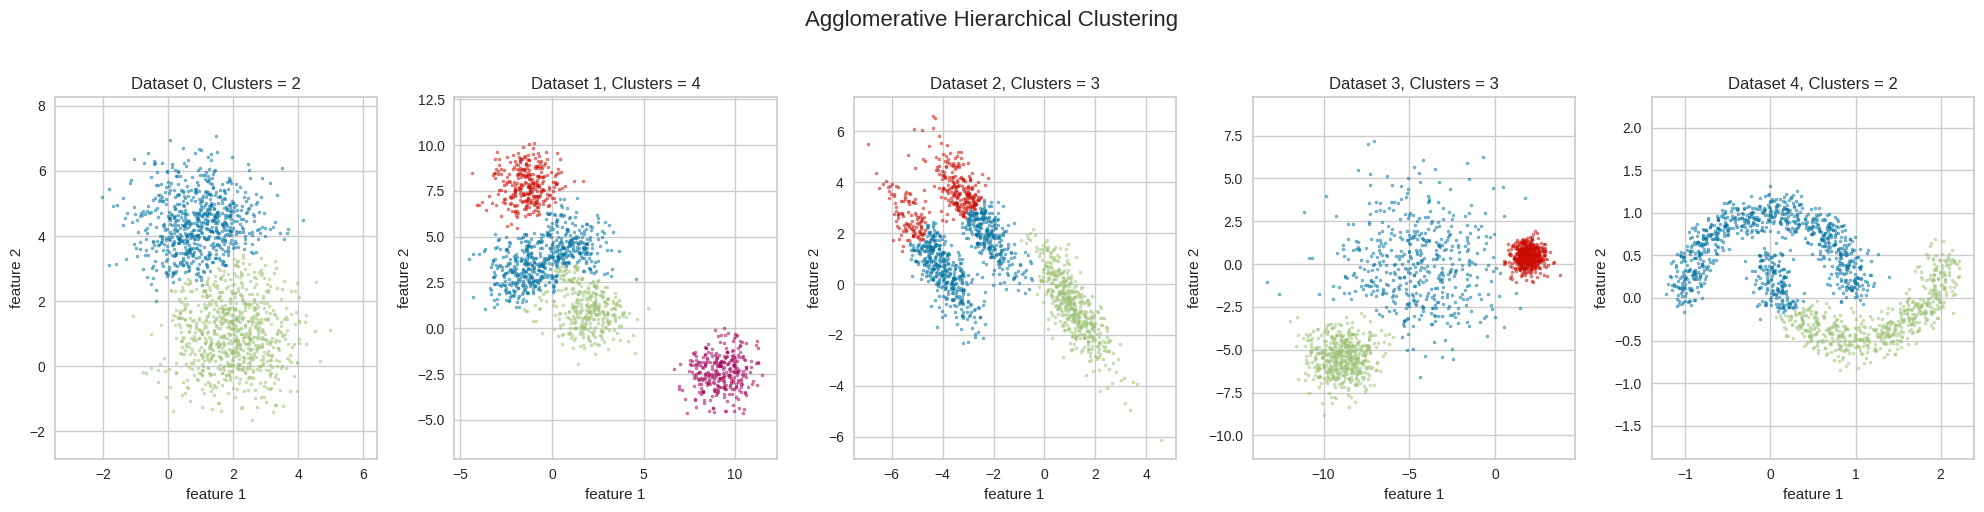

In [11]:
# Initialize an empty list to store AHC models
ahc_models = []

# Apply AHC for each dataset using the optimal_ks from K-means
for i, dataset in enumerate(x_scaled_datasets):
    # Initialize AgglomerativeClustering with the optimal k and Euclidean affinity
    # linkage='ward' is generally used for Euclidean distances
    model = AgglomerativeClustering(n_clusters=optimal_ks[i], linkage='ward')

    # Fit the model and get cluster labels
    model.fit(dataset)
    ahc_models.append(model)

# Plot clusters from each AHC model
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
fig.suptitle('Agglomerative Hierarchical Clustering', y=1.02, fontsize=16)
for i, model in enumerate(ahc_models):
    plot_cluster(ax[i], X[i], model.labels_)
    ax[i].set_title(f'Dataset {i}, Clusters = {optimal_ks[i]}')
plt.tight_layout()
plt.show()

### Comparing methods
**theoretically, DBSCAN should perform best with consistently dense, well-separated clusters, so I completed the following on that understanding**  

Dataset 0  
best: KMeans, AHC
worst: DBSCAN
  
Dataset 1  
best: KMeans (AHC)
worst: DBSCAN
  
Dataset 2  
best: DBSCAN
worst: AHC, (KMeans)
  
Dataset 3  
best: AHC, DBSCAN
worst: KMeans
  
Dataset 4  
best: DBSCAN  
worst: KMeans, AHC

**Kmeans**: low effort for good result, elbow diagrams make finding good k fairly straightforward.  
**DBSCAN**: Most/High effort for good result, I honestly gave up trying after a certain point.   
**AHC**: low effort for good result, just need to look at dendrogram and pick a cutoff k.  
  
KMeans excels with centroid-shaped clusters. DBSCAN excels with consistently dense clusters with clear separation. AHC excels with datasets suited to bottom-up clustering by merging clusters. It handles outliers poorly.

# 2

## [40 points] Dimensionality reduction and visualization of digits with PCA,  t-SNE, and another of your choice

**(a)** Reduce the dimensionality of the data with PCA for data visualization. Load the `scikit-learn` digits dataset (code provided to do this below). Apply PCA and reduce the data (with the associated cluster labels 0-9) into a 2-dimensional space. Plot the data with labels in this two dimensional space (labels can be colors, shapes, or using the actual numbers to represent the data - definitely include a legend in your plot).

**(b)** Create a plot showing the cumulative fraction of variance explained as you incorporate from $1$ through all $D$ principal components of the data (where $D$ is the dimensionality of the data).
- What fraction of variance in the data is UNEXPLAINED by the first two principal components of the data?
- Briefly comment on how this may impact how well-clustered the data are.
*You can use the `explained_variance_` attribute of the PCA module in `scikit-learn` to assist with this question*

**(c)** Reduce the dimensionality of the data with t-SNE for data visualization. T-distributed stochastic neighborhood embedding (t-SNE) is a nonlinear dimensionality reduction technique that is particularly adept at embedding the data into lower 2 or 3 dimensional spaces. Apply t-SNE using the `scikit-learn` implementation to the digits dataset and plot it in 2-dimensions (with associated cluster labels 0-9). You may need to adjust the parameters to get acceptable performance. You can read more about how to use t-SNE effectively [here](https://distill.pub/2016/misread-tsne/).

**(d)** Pick a third dimensionality reduction technique (for example LDA, UMAP, autoencoder, etc.).  Apply this technique to the same digits dataset and plot it in 2-dimensions (with associated cluster labels 0-9).

**(e)** Briefy compare/contrast the performance of these three techniques.
- Which seemed to cluster the data best and why?
- What about time considerations?
- Notice that t-SNE doesn't have a `fit` method, but only a `fit_transform` method. Why is this? What implications does this imply for using this method?
*Note: Remember that you typically will not have labels available in most problems.*


Code is provided for loading the data below.

In [12]:
################################
# Load the data
################################
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# load dataset
digits = datasets.load_digits()
n_sample = digits.target.shape[0]
n_feature = digits.images.shape[1] * digits.images.shape[2]
X_digits = np.zeros((n_sample, n_feature))
for i in range(n_sample):
    X_digits[i, :] = digits.images[i, :, :].flatten()
y_digits = digits.target

In [13]:
X_digits.shape

(1797, 64)

**ANSWER**

### Import libraries, define functions

In [14]:
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

In [15]:
# define plotting function with legend
def plot_2D_cluster_with_legend(data, title, alpha=0.5, size=20, showprint=False):
  '''Plot two-dimensional data clusters with legend
  '''
  # adjust for plotting
  new_data = np.hstack((data, y_digits.reshape(-1, 1)))

  #converting into dataframe
  plot_data = pd.DataFrame(data=new_data, columns=["1st", "2nd", "labels"])

  if showprint == True:
    print(plot_data.shape)
    plot_data.head(5)

  sns.FacetGrid(plot_data,
              hue="labels",
              height=5).map(sns.scatterplot,"1st","2nd", s=size, alpha=alpha).add_legend().fig.suptitle(title)
  plt.show()

### PCA

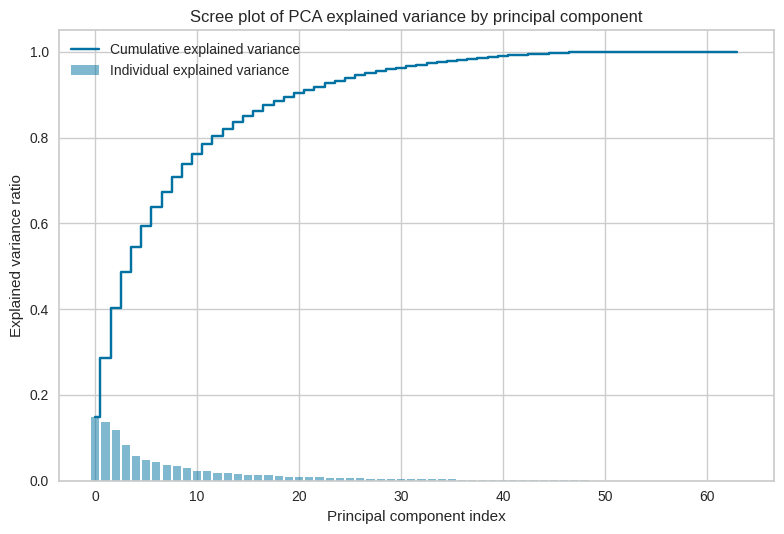

In [16]:
# reinit pca with all dimensionalities
pcaAll = PCA()
X_pcaAll = pcaAll.fit_transform(X_digits)

# Determine explained variance using explained_variance_ration_ attribute
exp_var_pca = pcaAll.explained_variance_ratio_

# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Create the visualization plot
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.title('Scree plot of PCA explained variance by principal component')
plt.tight_layout()
plt.show()

In [17]:
sscaler = StandardScaler()
X_digits = sscaler.fit_transform(X_digits)

# initialize pca
pca = PCA(n_components=2)

# fit pca
X_pca = pca.fit_transform(X_digits)

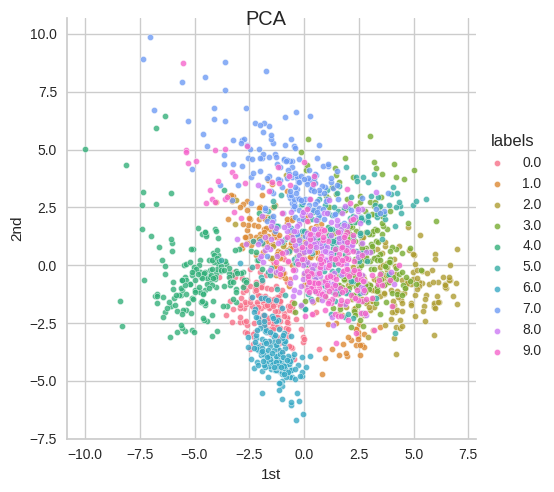

In [18]:
plot_2D_cluster_with_legend(X_pca, "PCA", alpha=0.8)

In [19]:
# cumulative variance explained by first 2 principal components
print(f'{cum_sum_eigenvalues[1]:.2}')

0.29


**PCA Comments**  
The above scree plot shows how much of the data variance is explained by each principal component individually and cumulatively. The first 2 PCs account for
22% of the cumulative variance, leaving 78% of the variance unexplained. This demonstrates that using only 2 PCs may not be ideal for maintaining high cluster quality. Similarly to the elbow method for KMeans, we want to find a reasonable number of principal components that encompasses much of the variance in the data. Using this number of PCs will be a good starting point to ensuring we create high fidelity clusters.



### tSNE

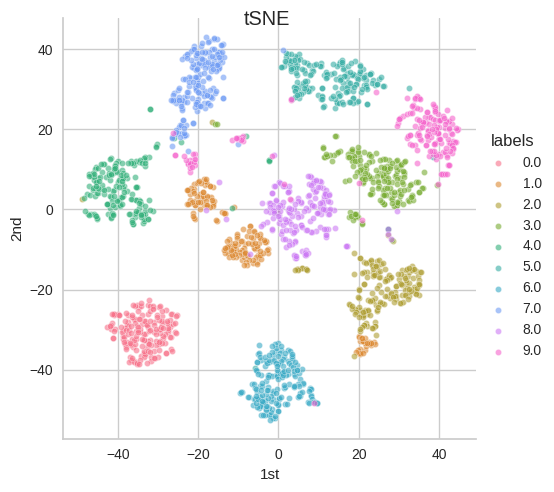

In [20]:
# apply tSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_digits)

# plot tSNE on 2D plot
plot_2D_cluster_with_legend(X_tsne, "tSNE", alpha=0.6)

### UMAP

In [21]:
# apply umap
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_digits)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


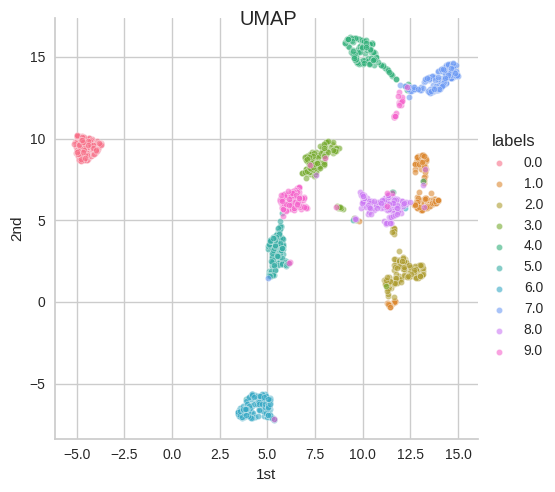

In [22]:
# plot Umap
plot_2D_cluster_with_legend(X_umap, "UMAP", alpha=0.6)

### Compare and Contrast
**best method**: UMAP has the highest density and most separated clusters. tSNE is a close second, while PCA is a blob of colors. UMAP also has a shorter runtime that tSNE (longest runtime). PCA is quick, but quality is lacking.

  
tSNE only has fit-transform method because it doesn't learn how to apply a fixed mapping function that it can apply to new data. It is only designed for unsupervised visualization of fixed datasets using gradient descent.  
This means that tSNE is not generalizable nor may it display the best clusters, particularly if the data sample is not representive of the population.   
  '  
  '  
  '  
  '  
  '  